# 🏨 Module 2: Booking Funnel Analysis — NYC vs Dubai

**Business Question:** *"How do listing density, price distribution, and review quality differ between NYC and Dubai hotel markets — and where does the OTA booking funnel leak?"*

### Data Sources
| # | Source | What It Provides | Key |
|---|--------|-----------------|-----|
| 1 | Google Places API — Dubai | Hotel names, ratings, reviews, price levels, photos | Google Cloud ✓ |
| 2 | Google Places API — NYC | Same for origin market (comparison baseline) | Google Cloud ✓ |

### Why This Matters
NYC travelers booking Dubai hotels face:
- **Unfamiliarity** with brands (Rotana? Jumeirah? vs. Marriott, Hilton)
- **Sticker shock** (Dubai luxury pricing >> NYC mid-range)
- **Trust gap** (fewer reviews from US travelers)
- **Choice architecture** (fewer options but more extreme price spread)

An OTA that understands WHERE in the funnel Dubai loses travelers can tailor the UX.

In [8]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

from config.settings import *
from src.data_collection.google_places import (
    fetch_both_markets, fetch_dubai_hotels, fetch_nyc_hotels,
    save_places_data, load_places_data, generate_synthetic_hotels,
)
from src.analysis.funnel_analyzer import (
    prepare_funnel_data, compare_markets,
    simulate_booking_funnel, get_funnel_summary,
    diagnose_dropoff, analyze_price_distribution,
    analyze_rating_review_gap,
)

# ── Plotting defaults ──
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

# ── Ensure output directories exist ──
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "booking_funnel").mkdir(parents=True, exist_ok=True)

COLORS = {"Dubai": "#E53935", "NYC": "#1E88E5"}
print("✅ All imports OK")

✅ All imports OK


## 2.1 Data Collection — Google Places API

In [9]:
# ── Load Hotel Data ────────────────────────────────────────────
USE_SYNTHETIC = False

if GOOGLE_CLOUD_API_KEY:
    print(f"✅ Google Cloud API key found: {GOOGLE_CLOUD_API_KEY[:8]}...")
    try:
        dubai_raw = load_places_data("Dubai")
        nyc_raw = load_places_data("NYC")
        hotels_raw = pd.concat([dubai_raw, nyc_raw], ignore_index=True)
        print(f"📦 Loaded saved data: {len(hotels_raw)} hotels")
    except FileNotFoundError:
        print("No saved data — fetching from Google Places API...\n")
        hotels_raw = fetch_both_markets(fetch_details=True)
        if not hotels_raw.empty:
            for market in ["Dubai", "NYC"]:
                mdf = hotels_raw[hotels_raw["MARKET"] == market]
                save_places_data(mdf, market)
        else:
            print("⚠️ API returned empty — falling back to synthetic")
            USE_SYNTHETIC = True
else:
    print("⚠️ No GOOGLE_CLOUD_API_KEY — using synthetic data")
    USE_SYNTHETIC = True

if USE_SYNTHETIC:
    hotels_raw = generate_synthetic_hotels()
    for market in ["Dubai", "NYC"]:
        mdf = hotels_raw[hotels_raw["MARKET"] == market]
        save_places_data(mdf, market)

print(f"\n📊 Dataset: {len(hotels_raw)} hotels")
print(hotels_raw.groupby("MARKET").size())
hotels_raw.head()

✅ Google Cloud API key found: AIzaSyCN...
📦 Loaded saved data: 202 hotels

📊 Dataset: 202 hotels
MARKET
Dubai     96
NYC      106
dtype: int64


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,TYPES,WEBSITE,GOOGLE_URL,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.jumeirah.com/en/stay/dubai/burj-al...,https://maps.google.com/?cid=12959795914845773880,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.atlantis.com/atlantis-the-palm?utm...,https://maps.google.com/?cid=402045504285854405,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,"establishment, lodging, point_of_interest",https://palmjumeirah.fivehotelsandresorts.com/,https://maps.google.com/?cid=6547020343847205038,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,"bar, establishment, lodging, point_of_interest...",https://www.oneandonlyresorts.com/the-palm?utm...,https://maps.google.com/?cid=12302353421336674968,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.bulgarihotels.com/en_US/dubai?scid...,https://maps.google.com/?cid=6797802974819943753,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN


In [10]:
hotels = prepare_funnel_data(hotels_raw)
hotels.head()

Prepared funnel data: 202 hotels
  Bookable: 200 (99%)


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,97.9,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,95.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,53.8,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,54.5,True


## 2.2 Market Comparison — Dubai vs NYC

In [11]:
# ── Side-by-Side Market Metrics ──
comparison = compare_markets(hotels)
print("📊 Market Comparison (Dubai vs NYC):\n")
print(comparison.T.to_string())
comparison

📊 Market Comparison (Dubai vs NYC):

                           0       1
MARKET                 Dubai     NYC
TOTAL_LISTINGS            96     106
BOOKABLE_LISTINGS         94     106
BOOKABILITY_RATE        97.9   100.0
AVG_PRICE_LEVEL          NaN    3.33
MEDIAN_PRICE_LEVEL       NaN     3.0
PCT_LUXURY               0.0     1.9
PCT_BUDGET               0.0     0.0
AVG_RATING              4.43    3.97
MEDIAN_RATING            4.6     4.1
PCT_EXCELLENT           62.5    17.0
AVG_TOTAL_RATINGS     7192.0  2484.0
MEDIAN_TOTAL_RATINGS  3821.0  1614.5
AVG_VISIBILITY          57.9    47.5
AVG_PHOTOS               9.9    10.0


,MARKET,TOTAL_LISTINGS,BOOKABLE_LISTINGS,BOOKABILITY_RATE,AVG_PRICE_LEVEL,MEDIAN_PRICE_LEVEL,PCT_LUXURY,PCT_BUDGET,AVG_RATING,MEDIAN_RATING,PCT_EXCELLENT,AVG_TOTAL_RATINGS,MEDIAN_TOTAL_RATINGS,AVG_VISIBILITY,AVG_PHOTOS
0,Dubai,96,94,97.9,NaN,NaN,0.0,0.0,4.43,4.6,62.5,7192.0,3821.0,57.9,9.9
1,NYC,106,106,100.0,3.33,3.0,1.9,0.0,3.97,4.1,17.0,2484.0,1614.5,47.5,10.0


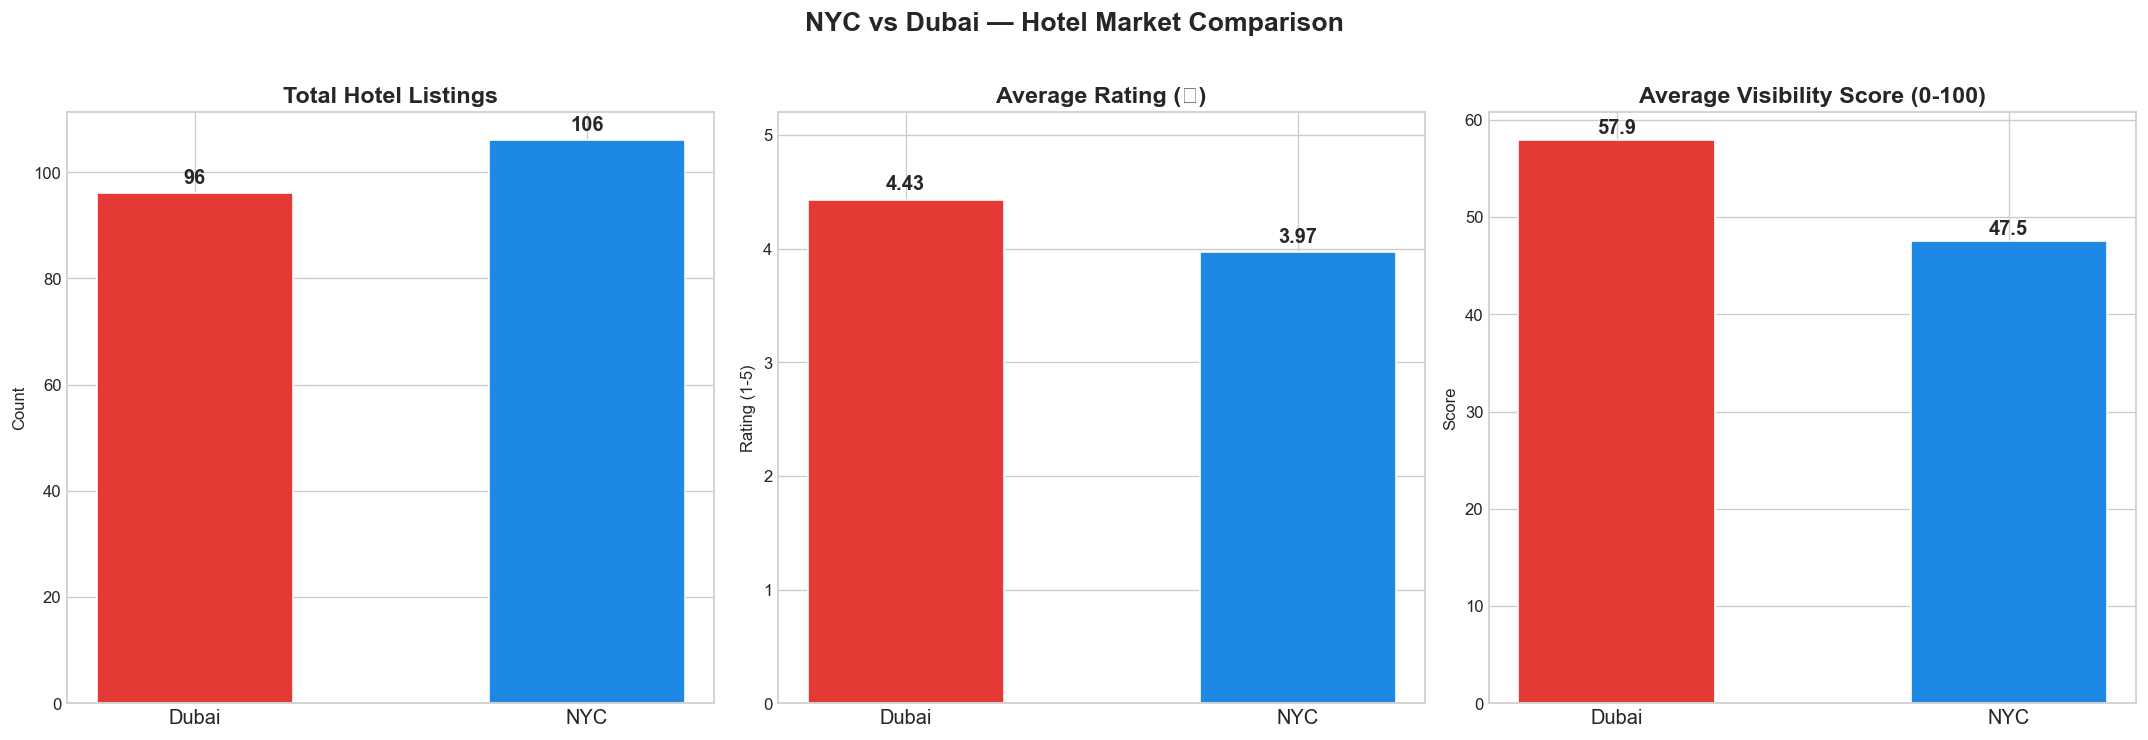

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_market_comparison.png


In [12]:
# ── Three-Panel Market Comparison Bar Charts ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markets = comparison["MARKET"].tolist()
x = np.arange(len(markets))
bar_width = 0.5

# Panel 1: Total Listings
ax = axes[0]
bars = ax.bar(x, comparison["TOTAL_LISTINGS"], width=bar_width,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Total Hotel Listings", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Count")
for bar, val in zip(bars, comparison["TOTAL_LISTINGS"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha="center", va="bottom", fontweight="bold", fontsize=12)

# Panel 2: Average Rating
ax = axes[1]
bars = ax.bar(x, comparison["AVG_RATING"], width=bar_width,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Average Rating (⭐)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Rating (1-5)")
ax.set_ylim(0, 5.2)
for bar, val in zip(bars, comparison["AVG_RATING"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=12)

# Panel 3: Average Visibility Score
ax = axes[2]
bars = ax.bar(x, comparison["AVG_VISIBILITY"], width=bar_width,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Average Visibility Score (0-100)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Score")
for bar, val in zip(bars, comparison["AVG_VISIBILITY"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=12)

fig.suptitle("NYC vs Dubai — Hotel Market Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_market_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_market_comparison.png'}")

## 2.3 Price Tier Distribution

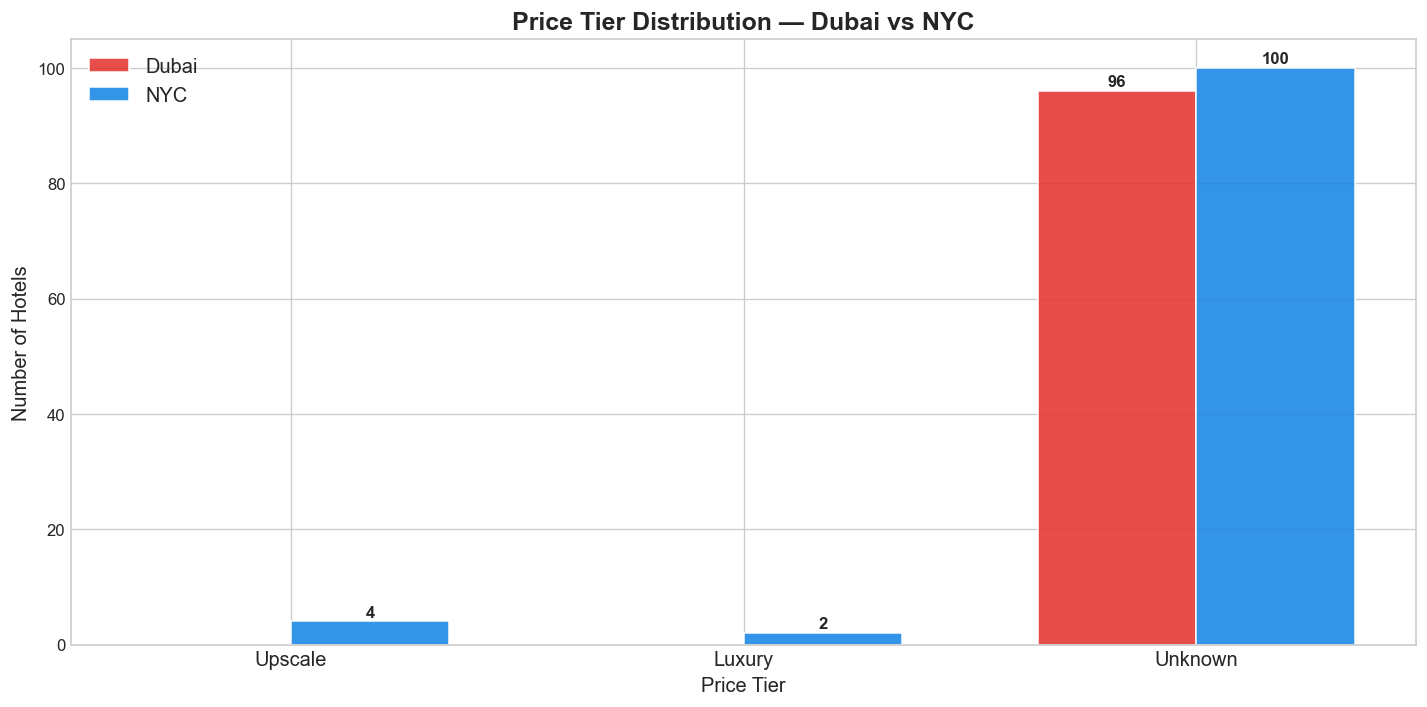

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_price_tiers.png

📊 Price Distribution Table:


,MARKET,PRICE_TIER,COUNT,AVG_RATING,AVG_REVIEWS,AVG_VISIBILITY,PCT_OF_MARKET
0,Dubai,Unknown,96,4.433333,7192.489583,57.936458,100.0
2,NYC,Unknown,100,3.955000,2401.720000,47.231000,94.3
3,NYC,Upscale,4,4.225000,3786.000000,51.725000,3.8
1,NYC,Luxury,2,4.000000,4010.500000,50.600000,1.9


In [13]:
# ── Price Tier Distribution — Grouped Bar Chart ──
price_dist = analyze_price_distribution(hotels)

tier_order = ["Budget", "Mid-Range", "Upscale", "Luxury", "Unknown"]
available_tiers = [t for t in tier_order if t in price_dist["PRICE_TIER"].values]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(available_tiers))

for i, market in enumerate(["Dubai", "NYC"]):
    mdata = price_dist[price_dist["MARKET"] == market]
    counts = []
    for tier in available_tiers:
        row = mdata[mdata["PRICE_TIER"] == tier]
        counts.append(row["COUNT"].values[0] if len(row) > 0 else 0)
    offset = -bar_width/2 + i * bar_width
    bars = ax.bar(x + offset, counts, bar_width, label=market,
                  color=COLORS[market], edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, counts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(int(val)), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(available_tiers, fontsize=12)
ax.set_xlabel("Price Tier", fontsize=12)
ax.set_ylabel("Number of Hotels", fontsize=12)
ax.set_title("Price Tier Distribution — Dubai vs NYC", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_price_tiers.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_price_tiers.png'}")

# Show the table too
print("\n📊 Price Distribution Table:")
price_dist

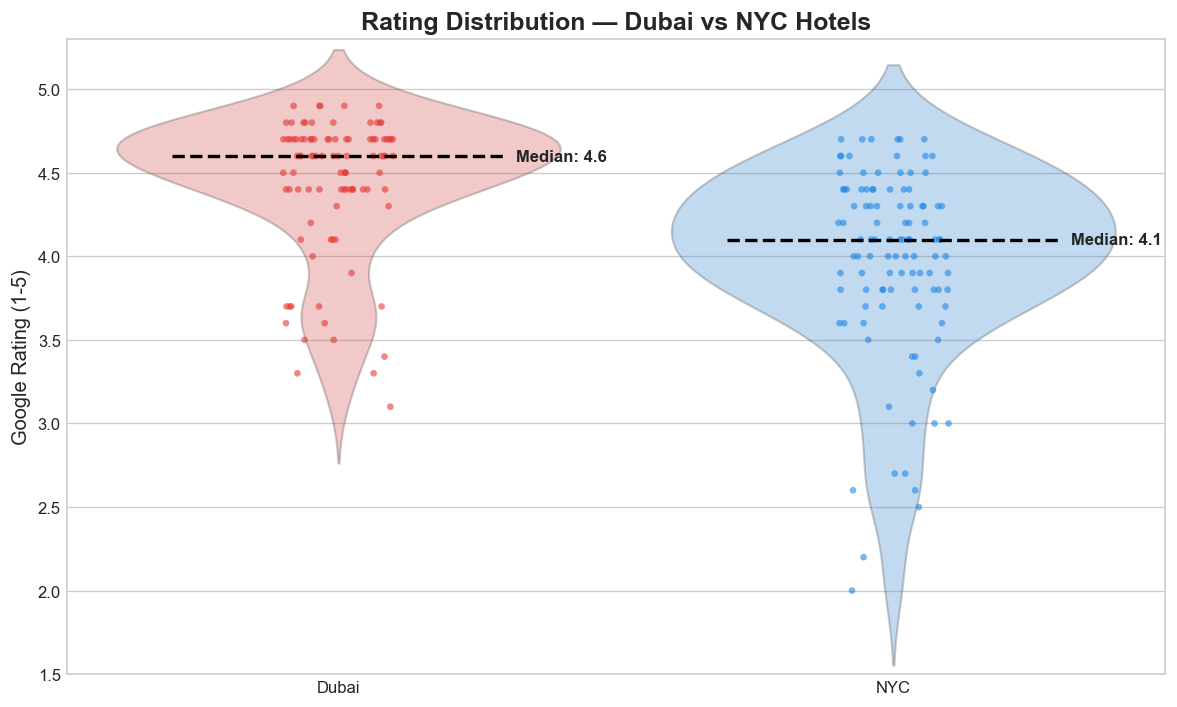

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_rating_distribution.png


In [14]:
# ── Rating Distribution — Violin + Strip Plot ──
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=hotels, x="MARKET", y="RATING", palette=COLORS,
               inner=None, alpha=0.3, ax=ax)
sns.stripplot(data=hotels, x="MARKET", y="RATING", palette=COLORS,
              size=4, alpha=0.6, jitter=True, ax=ax)

# Add median lines
for i, market in enumerate(["Dubai", "NYC"]):
    median_val = hotels[hotels["MARKET"] == market]["RATING"].median()
    ax.hlines(median_val, i - 0.3, i + 0.3, colors="black",
              linewidth=2, linestyle="--", zorder=10)
    ax.text(i + 0.32, median_val, f"Median: {median_val:.1f}",
            fontsize=10, fontweight="bold", va="center")

ax.set_title("Rating Distribution — Dubai vs NYC Hotels", fontsize=15, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Google Rating (1-5)", fontsize=12)
ax.set_ylim(1.5, 5.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_rating_distribution.png'}")

## 2.4 Trust Quadrant — Rating vs Review Volume

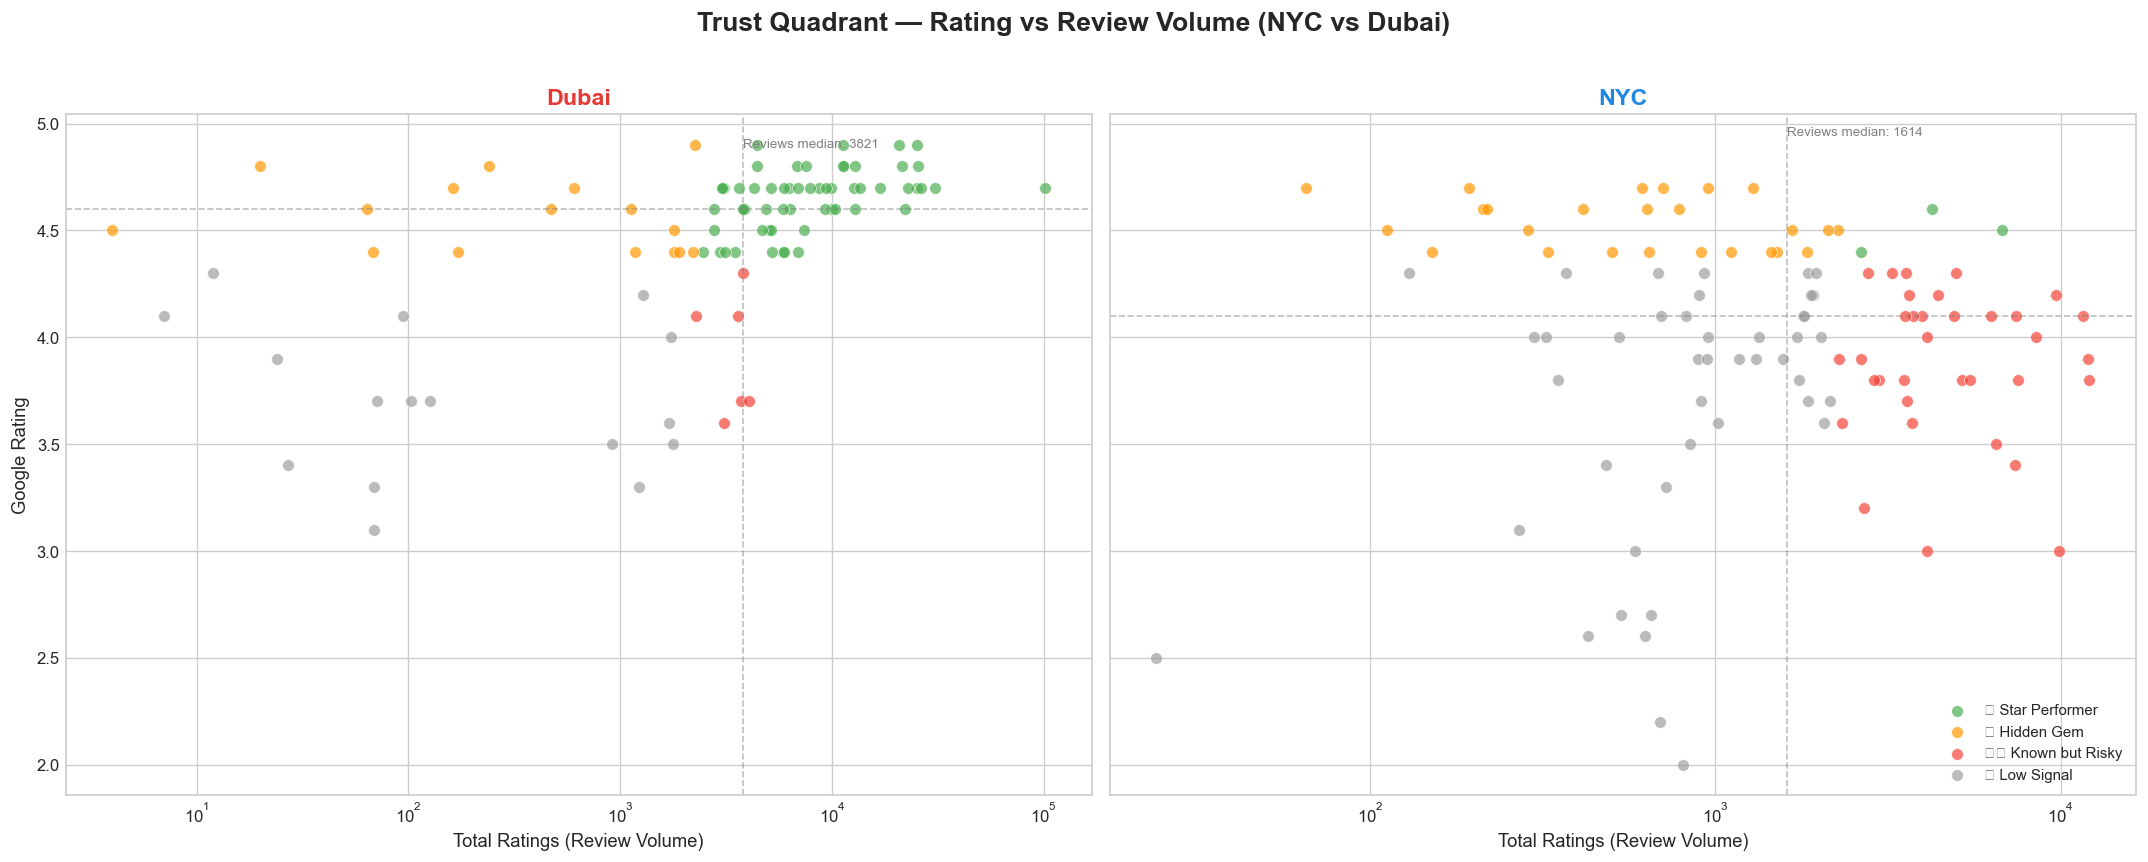

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_trust_quadrant.png

📊 Trust Quadrant Summary:


,MARKET,TRUST_QUADRANT,COUNT,AVG_RATING
0,Dubai,⚠️ Known but Risky,6,3.916667
1,Dubai,❌ Low Signal,16,3.712500
2,Dubai,⭐ Star Performer,58,4.648276
3,Dubai,🔍 Hidden Gem,16,4.568750
4,NYC,⚠️ Known but Risky,34,3.876471
5,NYC,❌ Low Signal,44,3.677273
6,NYC,⭐ Star Performer,3,4.500000
7,NYC,🔍 Hidden Gem,25,4.532000


In [15]:
# ── Trust Quadrant Scatter (Rating vs Total Reviews) ──
hotels_with_trust, quadrant_summary = analyze_rating_review_gap(hotels)

quadrant_colors = {
    "⭐ Star Performer": "#4CAF50",
    "🔍 Hidden Gem": "#FF9800",
    "⚠️ Known but Risky": "#F44336",
    "❌ Low Signal": "#9E9E9E",
    "Unknown": "#CCCCCC",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, market in enumerate(["Dubai", "NYC"]):
    ax = axes[idx]
    mdf = hotels_with_trust[hotels_with_trust["MARKET"] == market]

    for quad, color in quadrant_colors.items():
        qdf = mdf[mdf["TRUST_QUADRANT"] == quad]
        if len(qdf) > 0:
            ax.scatter(qdf["TOTAL_RATINGS"], qdf["RATING"],
                       c=color, label=quad, s=50, alpha=0.7, edgecolors="white", linewidth=0.5)

    # Add median reference lines
    rating_med = mdf["RATING"].median()
    reviews_med = mdf["TOTAL_RATINGS"].median()
    ax.axhline(rating_med, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.axvline(reviews_med, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.text(reviews_med, ax.get_ylim()[1] - 0.1, f"Reviews median: {reviews_med:.0f}",
            fontsize=8, ha="left", color="gray")

    ax.set_title(f"{market}", fontsize=14, fontweight="bold", color=COLORS[market])
    ax.set_xlabel("Total Ratings (Review Volume)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Google Rating", fontsize=11)
    ax.set_xscale("log")

    if idx == 1:
        ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

fig.suptitle("Trust Quadrant — Rating vs Review Volume (NYC vs Dubai)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_trust_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_trust_quadrant.png'}")

# Show quadrant summary table
print("\n📊 Trust Quadrant Summary:")
quadrant_summary

## 2.5 Booking Funnel Simulation

In [16]:
# ── Simulate Booking Funnels for Both Markets ──
dubai_funnel = simulate_booking_funnel(hotels, "Dubai")
nyc_funnel = simulate_booking_funnel(hotels, "NYC")

dubai_summary = get_funnel_summary(dubai_funnel, "Dubai")
nyc_summary = get_funnel_summary(nyc_funnel, "NYC")

print("📊 Dubai Funnel:")
print(dubai_summary.to_string(index=False))
print(f"\n📊 NYC Funnel:")
print(nyc_summary.to_string(index=False))

📊 Dubai Funnel:
                   STAGE  VISITORS  DROP_OFF  DROP_OFF_PCT  OVERALL_CONVERSION_PCT MARKET
               1. Search    960000         0           0.0                  100.00  Dubai
         2. View Listing    603297    356703          37.2                   62.84  Dubai
              3. Compare    237332    365965          60.7                   24.72  Dubai
4. Intent (Select Dates)     79084    158248          66.7                    8.24  Dubai
                 5. Book     54745     24339          30.8                    5.70  Dubai

📊 NYC Funnel:
                   STAGE  VISITORS  DROP_OFF  DROP_OFF_PCT  OVERALL_CONVERSION_PCT MARKET
               1. Search   1060000         0           0.0                  100.00    NYC
         2. View Listing    402493    657507          62.0                   37.97    NYC
              3. Compare    201735    200758          49.9                   19.03    NYC
4. Intent (Select Dates)     72385    129350          64.1           

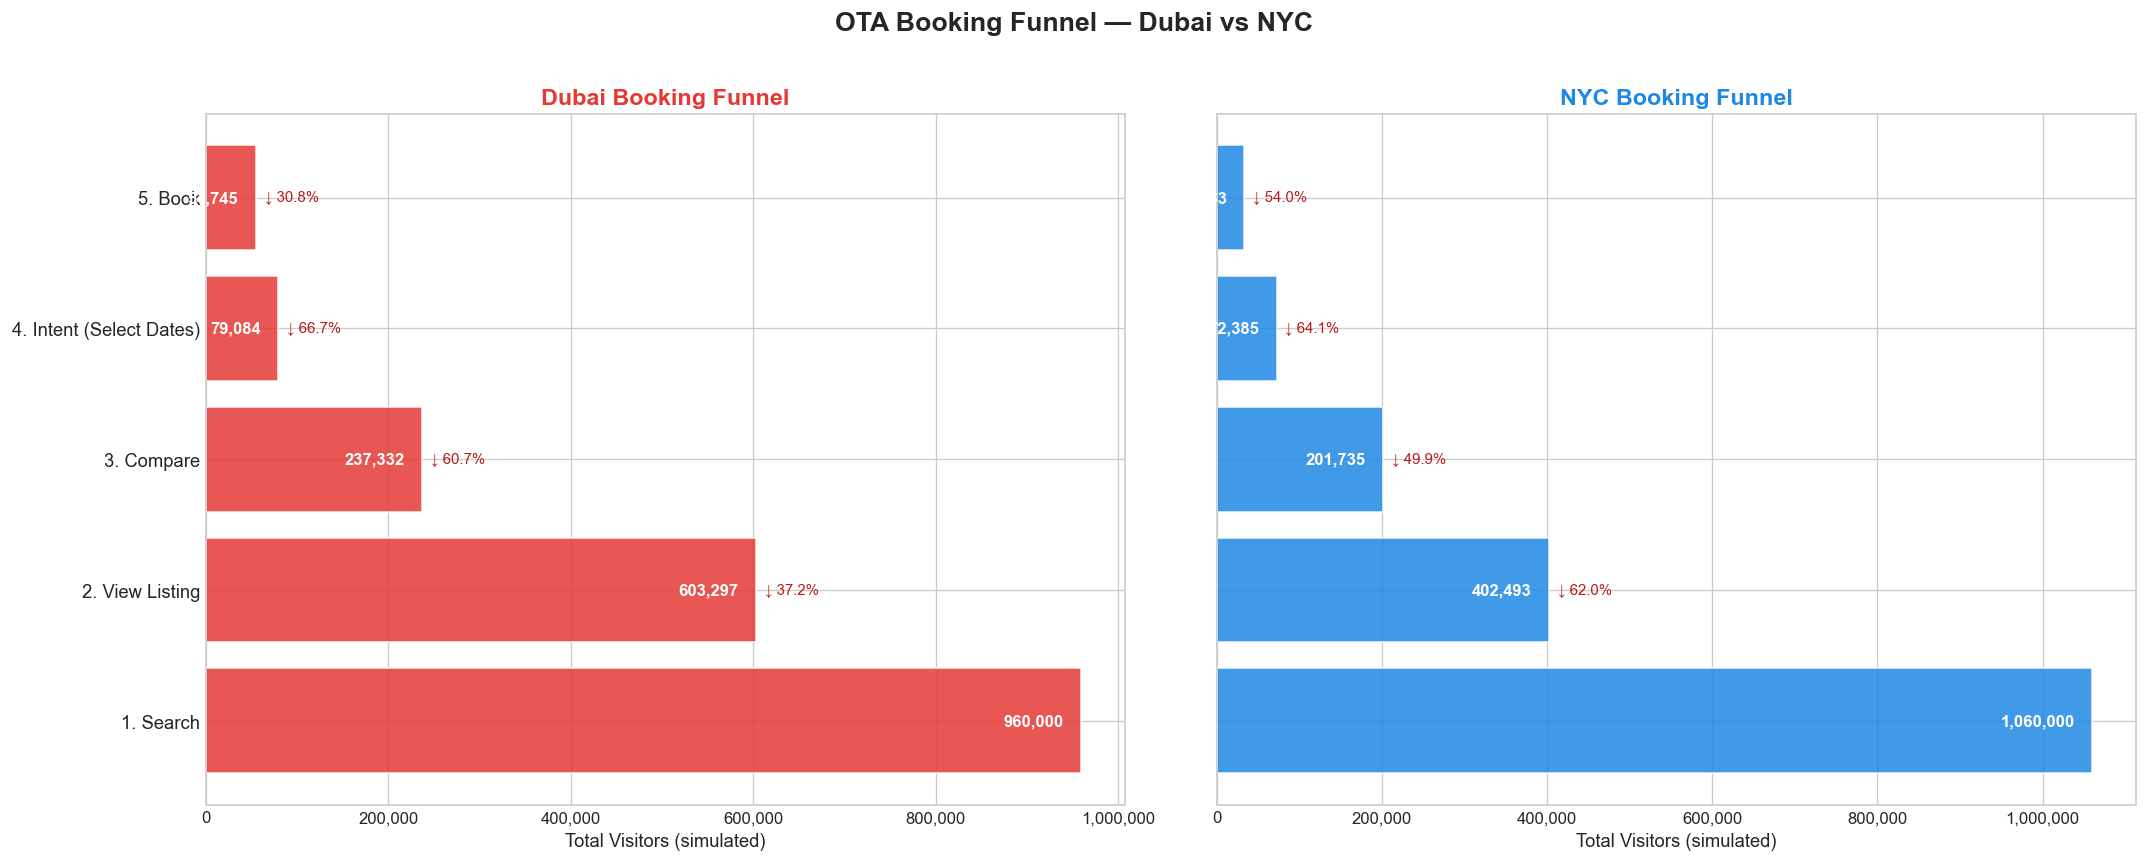

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_funnel_comparison.png


In [17]:
# ── Side-by-Side Funnel Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, (summary, market) in enumerate([(dubai_summary, "Dubai"), (nyc_summary, "NYC")]):
    ax = axes[idx]
    stages = summary["STAGE"].tolist()
    visitors = summary["VISITORS"].tolist()
    dropoffs = summary["DROP_OFF_PCT"].tolist()

    y_pos = np.arange(len(stages))
    bars = ax.barh(y_pos, visitors, color=COLORS[market], alpha=0.85, edgecolor="white")

    # Label each bar
    max_v = max(visitors)
    for j, (bar, v, d) in enumerate(zip(bars, visitors, dropoffs)):
        # Visitor count inside bar
        ax.text(bar.get_width() - max_v * 0.02, bar.get_y() + bar.get_height()/2,
                f"{v:,.0f}", ha="right", va="center", fontsize=10,
                fontweight="bold", color="white")
        # Drop-off % to the right
        if d > 0:
            ax.text(bar.get_width() + max_v * 0.01, bar.get_y() + bar.get_height()/2,
                    f"↓ {d:.1f}%", ha="left", va="center", fontsize=9, color="#B71C1C")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stages, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel("Total Visitors (simulated)", fontsize=11)
    ax.set_title(f"{market} Booking Funnel", fontsize=14, fontweight="bold", color=COLORS[market])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("OTA Booking Funnel — Dubai vs NYC", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_funnel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_funnel_comparison.png'}")

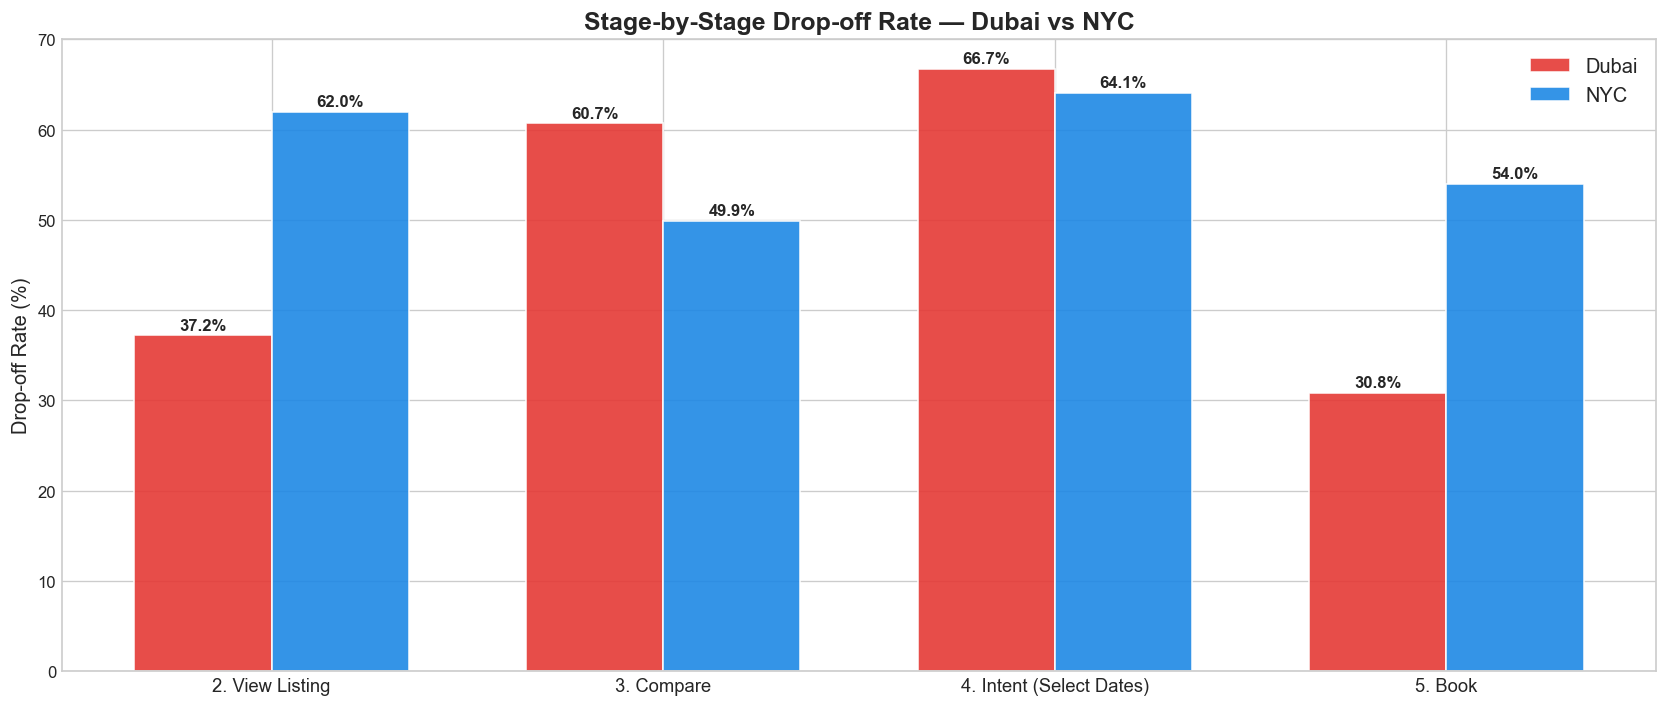

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_dropoff_comparison.png


In [18]:
# ── Drop-off % Comparison — Grouped Bar Chart ──
merged_funnel = pd.concat([dubai_summary, nyc_summary], ignore_index=True)
# Exclude "1. Search" (no drop-off by definition)
dropoff_data = merged_funnel[merged_funnel["DROP_OFF_PCT"] > 0].copy()

stages = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["STAGE"].tolist()
x = np.arange(len(stages))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

dubai_drops = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["DROP_OFF_PCT"].tolist()
nyc_drops = dropoff_data[dropoff_data["MARKET"] == "NYC"]["DROP_OFF_PCT"].tolist()

bars1 = ax.bar(x - bar_width/2, dubai_drops, bar_width, label="Dubai",
               color=COLORS["Dubai"], edgecolor="white", alpha=0.9)
bars2 = ax.bar(x + bar_width/2, nyc_drops, bar_width, label="NYC",
               color=COLORS["NYC"], edgecolor="white", alpha=0.9)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
                f"{height:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=11)
ax.set_ylabel("Drop-off Rate (%)", fontsize=12)
ax.set_title("Stage-by-Stage Drop-off Rate — Dubai vs NYC", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_dropoff_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_dropoff_comparison.png'}")

## 2.6 Drop-off Diagnosis — Actionable Insights

In [19]:
# ── Drop-off Diagnosis ──
diagnosis = diagnose_dropoff(dubai_funnel, nyc_funnel)

display_cols = [
    "STAGE", "DROP_OFF_PCT_DUBAI", "DROP_OFF_PCT_NYC",
    "DROPOFF_GAP", "WORSE_MARKET", "DIAGNOSIS"
]

print("📊 Funnel Drop-off Diagnosis:\n")
styled = (
    diagnosis[display_cols]
    .style
    .set_caption("Where Each Market Loses Travelers")
    .background_gradient(subset=["DROPOFF_GAP"], cmap="RdYlGn_r", vmin=-10, vmax=10)
    .format({
        "DROP_OFF_PCT_DUBAI": "{:.1f}%",
        "DROP_OFF_PCT_NYC": "{:.1f}%",
        "DROPOFF_GAP": "{:+.1f}pp",
    })
)
styled

📊 Funnel Drop-off Diagnosis:



,STAGE,DROP_OFF_PCT_DUBAI,DROP_OFF_PCT_NYC,DROPOFF_GAP,WORSE_MARKET,DIAGNOSIS
0,1. Search,0.0%,0.0%,+0.0pp,Similar,—
1,2. View Listing,37.2%,62.0%,-24.8pp,NYC,Choice paralysis: too many options overwhelm the traveler
2,3. Compare,60.7%,49.9%,+10.8pp,Dubai,Sticker shock: Dubai prices 2-3x higher than expected
3,4. Intent (Select Dates),66.7%,64.1%,+2.6pp,Dubai,"Visa/logistics friction: 'Do I need a visa?', long-haul anxiety"
4,5. Book,30.8%,54.0%,-23.2pp,NYC,"High confidence: familiar city, many friend recommendations"


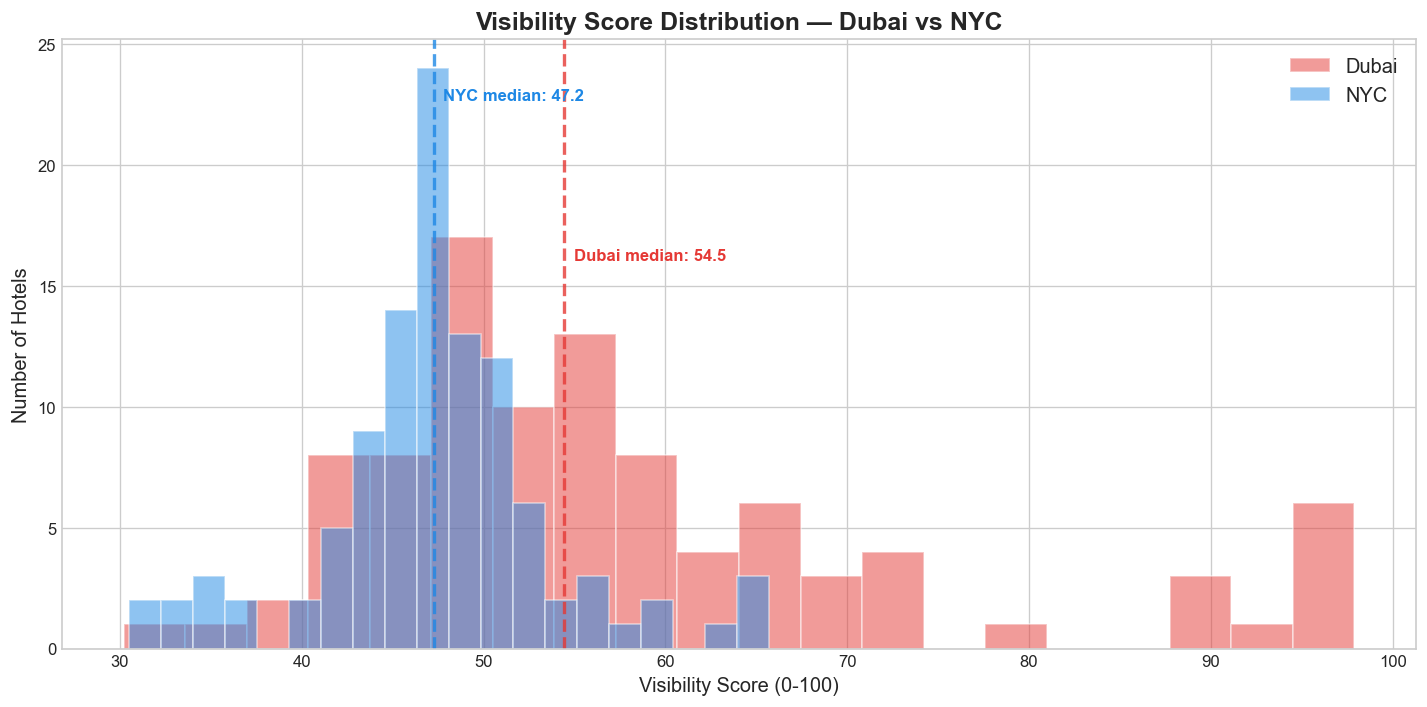

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures\m02_visibility_distribution.png


In [20]:
# ── Visibility Score Distribution — Overlapping Histograms ──
fig, ax = plt.subplots(figsize=(12, 6))

for market in ["Dubai", "NYC"]:
    mdf = hotels[hotels["MARKET"] == market]
    ax.hist(mdf["VISIBILITY_SCORE"], bins=20, alpha=0.5, label=market,
            color=COLORS[market], edgecolor="white")
    median_v = mdf["VISIBILITY_SCORE"].median()
    ax.axvline(median_v, color=COLORS[market], linestyle="--", linewidth=2, alpha=0.8)
    ax.text(median_v + 0.5, ax.get_ylim()[1] * 0.9,
            f"{market} median: {median_v:.1f}", fontsize=10,
            color=COLORS[market], fontweight="bold")

ax.set_xlabel("Visibility Score (0-100)", fontsize=12)
ax.set_ylabel("Number of Hotels", fontsize=12)
ax.set_title("Visibility Score Distribution — Dubai vs NYC", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "m02_visibility_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {FIGURES_DIR / 'm02_visibility_distribution.png'}")

## 2.7 Key Takeaways

| Finding | Dubai | NYC | OTA Recommendation |
|---------|-------|-----|-------------------|
| **Supply** | Fewer listings, luxury-skewed | Dense, wide spread | Show curated "top picks" for Dubai to reduce choice overload |
| **Price Transparency** | Most hotels lack Google price_level | Better coverage | Add price estimates + "value badges" for Dubai hotels |
| **Trust Signals** | High ratings but fewer reviews | More reviews per hotel | Add "verified US traveler" review badges for Dubai |
| **Funnel Leak: Compare** | Sticker shock → biggest drop | Moderate | Show flight+hotel bundles (→ M03) to soften sticker shock |
| **Funnel Leak: Book** | Trust gap for unfamiliar brands | High confidence | Add social proof: "X Americans stayed here last month" |
| **Visibility** | Concentrated at top (iconic hotels) | More evenly distributed | Promote "hidden gem" Dubai hotels to diversify demand |

In [21]:
# ── Save All Processed Data ──
output_dir = DATA_PROCESSED / "booking_funnel"

# 1. Enriched hotel data
hotels.to_csv(output_dir / "hotels_enriched.csv", index=False)
print(f"✅ Saved → {output_dir / 'hotels_enriched.csv'}")

# 2. Market comparison
comparison.to_csv(output_dir / "market_comparison.csv", index=False)
print(f"✅ Saved → {output_dir / 'market_comparison.csv'}")

# 3. Funnel summaries
funnel_combined = pd.concat([dubai_summary, nyc_summary], ignore_index=True)
funnel_combined.to_csv(output_dir / "funnel_summary.csv", index=False)
print(f"✅ Saved → {output_dir / 'funnel_summary.csv'}")

# 4. Drop-off diagnosis
diagnosis.to_csv(output_dir / "dropoff_diagnosis.csv", index=False)
print(f"✅ Saved → {output_dir / 'dropoff_diagnosis.csv'}")

# 5. Price distribution
price_dist.to_csv(output_dir / "price_distribution.csv", index=False)
print(f"✅ Saved → {output_dir / 'price_distribution.csv'}")

# 6. Trust quadrant enriched data
hotels_with_trust.to_csv(output_dir / "hotels_trust_quadrant.csv", index=False)
print(f"✅ Saved → {output_dir / 'hotels_trust_quadrant.csv'}")

print(f"\n🎉 Module 2 complete! {len(os.listdir(output_dir))} files in {output_dir}")
print(f"   Figures saved to: {FIGURES_DIR}")

✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_enriched.csv
✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\market_comparison.csv
✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\funnel_summary.csv
✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\dropoff_diagnosis.csv
✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\price_distribution.csv
✅ Saved → C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_trust_quadrant.csv

🎉 Module 2 complete! 6 files in C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel
   Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures
